Raw_Data shape: (10000, 31744)
nx=100, ny=100
ncycle, ndc, nfield, nfreq:  8 32 2 62
raw_phys shape: (100, 100, 8, 32, 2, 62)
sidpy.Dataset of type IMAGE_STACK with:
 dask.array<array, shape=(100, 100, 8, 32, 2, 62), dtype=complex64, chunksize=(32, 32, 8, 32, 2, 32), chunktype=numpy.ndarray>
 data contains: generic (a.u.)
 and Dimensions: 
y:  generic (px) of size (100,)
x:  generic (px) of size (100,)
cycle:  generic (idx) of size (8,)
DC_bias:  generic (V) of size (32,)
field:  generic (idx) of size (2,)
frequency:  generic (Hz) of size (62,)


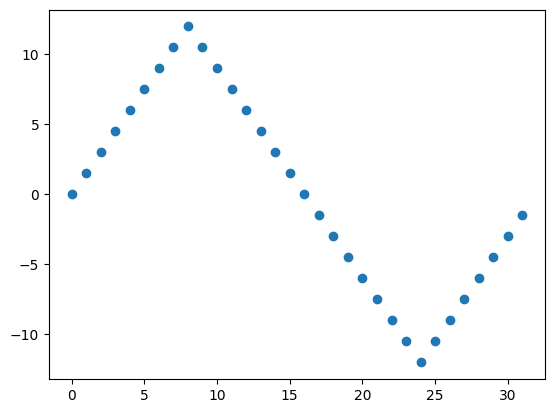

In [230]:
#Sidpy fitting
'''
This file will contain a class that is used for SHO fitting for sidpy datasets
for now I am just dumping the code from the notebook, but essentially this should be it's own class that is instantiated with the BEPS dataset
THen it should be able to do sho fitting and maybe loop fitting.

'''

# import numpy as np
import time
import h5py

import pyNSID
import matplotlib.pyplot as plt
import numba

import sidpy
#Let's open up a sample dataset and see...

import SciFiReaders as sr
from scipy.optimize import curve_fit
import numpy as np



def SHO_fit_flattened(wvec,*p):
    Amp, w_0, Q, phi=p[0],p[1],p[2],p[3]
    func = Amp * np.exp(1.j * phi) * w_0 ** 2 / (wvec ** 2 - 1j * wvec * w_0 / Q - w_0 ** 2)
    return np.hstack([np.real(func),np.imag(func)])

def SHO_fit_abs(wvec,*p):
    Amp, w_0, Q, phi=p[0],p[1],p[2],p[3]
    func = Amp * np.exp(1.j * phi) * w_0 ** 2 / (wvec ** 2 - 1j * wvec * w_0 / Q - w_0 ** 2)
    return np.abs(func)

def my_guess_fn(freq_vec,ydata):
    ydata = np.array(ydata)
    amp_guess = np.abs(ydata)[np.argmax(np.abs(ydata))]
    Q_guess = 50
    max_min_ratio = np.max(abs(ydata)) / np.min(abs(ydata))
    phi_guess = np.angle(ydata)[np.argmax(np.abs(ydata))]
    w_guess = freq_vec[np.argmax(np.abs(ydata))]
    
    #Let's just run some Q values to find the closest one
    Q_values = [5,10,20,50,100,200,500]
    err_vals = []
    for q_val in Q_values:
        p_test = [amp_guess/q_val, w_guess, q_val, phi_guess]
        func_out = SHO_fit_flattened(freq_vec,*p_test)
        complex_output = func_out[:len(func_out)//2] + 1j*func_out[(len(func_out)//2):] 
        amp_output = np.abs(complex_output)
        err = np.mean((amp_output - np.abs(ydata))**2)
        err_vals.append(err)
    Q_guess = Q_values[np.argmin(err_vals)]
    p0 = [amp_guess/Q_guess, w_guess, Q_guess, phi_guess]
    return p0


#Complex Gaussian Guess function
from numpy import exp, abs, sqrt, sum, real, imag, arctan2, append

def SHOestimateGuess(w_vec, resp_vec, num_points=5):
    """
    Generates good initial guesses for fitting

    Parameters
    ------------
    w_vec : 1D numpy array or list
        Vector of BE frequencies
    resp_vec : 1D complex numpy array or list
        BE response vector as a function of frequency
    num_points : (Optional) unsigned int
        Quality factor of the SHO peak

    Returns
    ---------
    retval : tuple
        SHO fit parameters arranged as amplitude, frequency, quality factor, phase
    """

    ii = np.argsort(abs(resp_vec))[::-1]

    a_mat = np.array([])
    e_vec = np.array([])
    
    for c1 in range(num_points):
        for c2 in range(c1 + 1, num_points):
            w1 = w_vec[ii[c1]]
            w2 = w_vec[ii[c2]]
            X1 = real(resp_vec[ii[c1]])
            X2 = real(resp_vec[ii[c2]])
            Y1 = imag(resp_vec[ii[c1]])
            Y2 = imag(resp_vec[ii[c2]])

            denom = (w1 * (X1 ** 2 - X1 * X2 + Y1 * (Y1 - Y2)) + w2 * (-X1 * X2 + X2 ** 2 - Y1 * Y2 + Y2 ** 2))
            if denom > 0:
                a = ((w1 ** 2 - w2 ** 2) * (w1 * X2 * (X1 ** 2 + Y1 ** 2) - w2 * X1 * (X2 ** 2 + Y2 ** 2))) / denom
                b = ((w1 ** 2 - w2 ** 2) * (w1 * Y2 * (X1 ** 2 + Y1 ** 2) - w2 * Y1 * (X2 ** 2 + Y2 ** 2))) / denom
                c = ((w1 ** 2 - w2 ** 2) * (X2 * Y1 - X1 * Y2)) / denom
                d = (w1 ** 3 * (X1 ** 2 + Y1 ** 2) -
                     w1 ** 2 * w2 * (X1 * X2 + Y1 * Y2) -
                     w1 * w2 ** 2 * (X1 * X2 + Y1 * Y2) +
                     w2 ** 3 * (X2 ** 2 + Y2 ** 2)) / denom

                if d > 0:
                    a_mat = append(a_mat, [a, b, c, d])

                    A_fit = abs(a + 1j * b) / d
                    w0_fit = sqrt(d)
                    Q_fit = -sqrt(d) / c
                    phi_fit = arctan2(-b, -a)

                    H_fit = A_fit * w0_fit ** 2 * exp(1j * phi_fit) / (
                        w_vec ** 2 - 1j * w_vec * w0_fit / Q_fit - w0_fit ** 2)

                    e_vec = append(e_vec,
                                   sum((real(H_fit) - real(resp_vec)) ** 2) +
                                   sum((imag(H_fit) - imag(resp_vec)) ** 2))
    if a_mat.size > 0:
        a_mat = a_mat.reshape(-1, 4)

        weight_vec = (1 / e_vec) ** 4
        w_sum = sum(weight_vec)

        a_w = sum(weight_vec * a_mat[:, 0]) / w_sum
        b_w = sum(weight_vec * a_mat[:, 1]) / w_sum
        c_w = sum(weight_vec * a_mat[:, 2]) / w_sum
        d_w = sum(weight_vec * a_mat[:, 3]) / w_sum

        A_fit = abs(a_w + 1j * b_w) / d_w
        w0_fit = sqrt(d_w)
        Q_fit = -sqrt(d_w) / c_w
        phi_fit = np.arctan2(-b_w, -a_w)

        H_fit = A_fit * w0_fit ** 2 * exp(1j * phi_fit) / (w_vec ** 2 - 1j * w_vec * w0_fit / Q_fit - w0_fit ** 2)

        if np.std(abs(resp_vec)) / np.std(abs(resp_vec - H_fit)) < 1.2 or w0_fit < np.min(w_vec) or w0_fit > np.max(
                w_vec):
            p0 = SHOfastGuess(w_vec, resp_vec)
        else:
            p0 = np.array([A_fit, w0_fit, Q_fit, phi_fit])
    else:
        p0 = SHOfastGuess(w_vec, resp_vec)

    return p0

def SHOfastGuess(w_vec, resp_vec, qual_factor=200):
    """
    Default SHO guess from the maximum value of the response

    Parameters
    ------------
    w_vec : 1D numpy array or list
        Vector of BE frequencies
    resp_vec : 1D complex numpy array or list
        BE response vector as a function of frequency
    qual_factor : float
        Quality factor of the SHO peak

    Returns
    -------
    retval : 1D numpy array
        SHO fit parameters arranged as [amplitude, frequency, quality factor, phase]
    """
    amp_vec = abs(resp_vec)
    i_max = int(len(resp_vec) / 2)
    return np.array([np.mean(amp_vec) / qual_factor, w_vec[i_max], qual_factor, np.angle(resp_vec[i_max])])


#Now let's fit them all with sidpy
#Let's try sidpy fitter
#Instantiate the SidFitter class
"""
p0 = SHOestimateGuess(freq_vec, ydata)

lb = [1E-6, freq_vec.min(), 50, -2*np.pi]
ub = [1E-3, freq_vec.max(), 500, 2*np.pi]


fitter = sidpy.proc.fitter.SidFitter(beps_small, SHO_fit_flattened,num_workers=1,
                                     guess_fn = SHOestimateGuess,ind_dims=[0,1,3,4],
                           threads=1, return_cov=False, return_fit=False, return_std=False,
                           km_guess=True,num_fit_parms = 4, n_clus = 5)

n_workers = 8
    #for n_workers in [2,4,8]:
        
fitter = sidpy.proc.fitter.SidFitter(beps_small, SHO_fit_flattened,num_workers=n_workers,
                                     guess_fn = SHOestimateGuess,ind_dims=[0,1,3,4],
                           threads=1, return_cov=False, return_fit=False, return_std=False,
                           km_guess=True,num_fit_parms = 4, n_clus = 4)
"""

import h5py
import sidpy
import numpy as np
from sidpy.sid import Dataset, Dimension
import matplotlib.pyplot as plt
from sidpy.proc.fitter import SidFitter
import time
from sklearn.metrics import r2_score
from joblib import Parallel, delayed

exp_no = '2c'

input_file = "inputs/data/BEPS_1d7um_0009.h5"
h5_f = h5py.File(input_file, 'r')

raw_data = np.array(h5_f['/Measurement_000/Channel_000/Raw_Data'])
pos_vals = np.array(h5_f['/Measurement_000/Channel_000/Position_Values'])
spec_vals = np.array(h5_f['/Measurement_000/Channel_000/Spectroscopic_Values'])
print("Raw_Data shape:", raw_data.shape)

x_vals_full = pos_vals[:, 1]
y_vals_full = pos_vals[:, 0]
x_vals = np.unique(x_vals_full)
y_vals = np.unique(y_vals_full)
nx, ny = len(x_vals), len(y_vals)
print(f"nx={nx}, ny={ny}")

ny, nx, ncycle, ndc, nfield, nfreq = 100, 100, 8, 32, 2, 62

freq = spec_vals[0, :].reshape(ncycle, ndc, nfield, nfreq)[0,0,0,:]
dc_bias = spec_vals[1, :].reshape(ncycle, ndc, nfield, nfreq)[0,:,0,0]
field = spec_vals[2, :].reshape(ncycle, ndc, nfield, nfreq)[0,0,:,0]
cycle = spec_vals[3, :].reshape(ncycle, ndc, nfield, nfreq)[:,0,0,0]

ncycle, ndc, nfield, nfreq = len(cycle), len(dc_bias), len(field), len(freq)
print('ncycle, ndc, nfield, nfreq: ', ncycle, ndc, nfield, nfreq)

a = dc_bias
plt.scatter(np.arange(len(a)), a)

raw_phys = raw_data.reshape(ny, nx, ncycle, ndc, nfield, nfreq)
# raw_phys = np.transpose(raw_phys, (1, 0, 5, 3, 4, 2)) # (nx, ny, n_freq, n_dc, n_field, n_cycle)
print("raw_phys shape:", raw_phys.shape)  

beps_raw = Dataset.from_array(raw_phys, title='BEPS Raw Data')
beps_raw.data_type = 'image_stack'
beps_raw.units = 'a.u.'
beps_raw.set_dimension(0, Dimension(y_vals, name='y', units='px'))
beps_raw.set_dimension(1, Dimension(x_vals, name='x', units='px'))
beps_raw.set_dimension(2, Dimension(cycle, name='cycle', units='idx'))
beps_raw.set_dimension(3, Dimension(dc_bias, name='DC_bias', units='V'))
beps_raw.set_dimension(4, Dimension(field, name='field', units='idx'))
beps_raw.set_dimension(5, Dimension(freq, name='frequency', units='Hz'))

print(beps_raw)

In [231]:
## clean

In [232]:
## check 1: does this need axis correction? no, currently having (ny, nx, ncycle, ndc, nfield, nfreq) is good but check by plotting img with origin lower.

In [233]:
import numpy as np
import matplotlib.pyplot as plt

In [234]:
data = np.load(f"outputs/2a_fit_data_clean.npz")
sho_fit_params = data["sho_fit_params"]
sho_fit_curves = data["sho_fit_curves"]
sho_fit_r2 = data["sho_fit_r2"]

print(sho_fit_params.shape, sho_fit_curves.shape, sho_fit_r2.shape)

(50, 50, 8, 32, 2, 4) (50, 50, 8, 32, 2, 124) (50, 50, 8, 32, 2)


(array([3.000000e+00, 3.200000e+01, 3.760000e+02, 4.617000e+03,
        1.619000e+03, 6.779000e+03, 1.268000e+04, 2.126800e+04,
        4.403100e+04, 1.188595e+06]),
 array([-0.61199155, -0.45087822, -0.28976489, -0.12865156,  0.03246177,
         0.1935751 ,  0.35468843,  0.51580177,  0.6769151 ,  0.83802843,
         0.99914176]),
 <BarContainer object of 10 artists>)

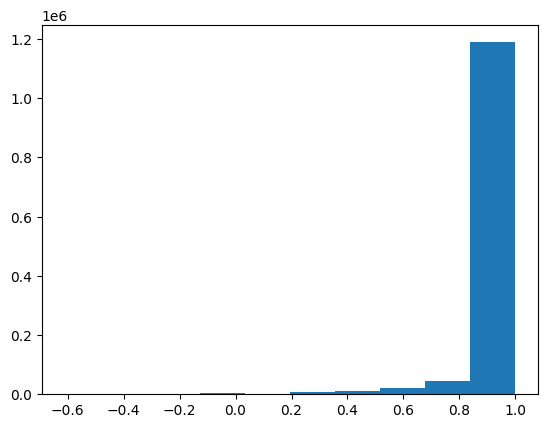

In [235]:
plt.hist(sho_fit_r2.flatten())

(50, 50, 8, 32)
(50, 50)


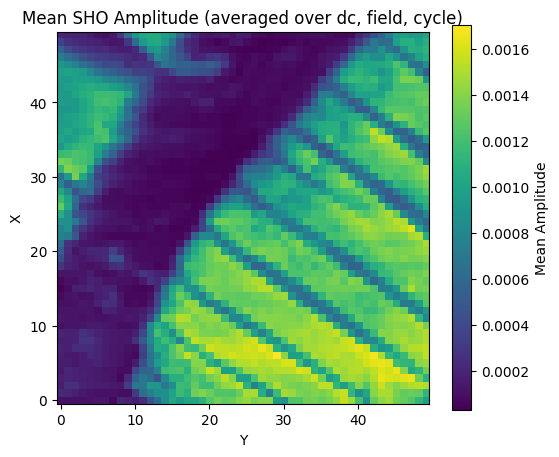

In [236]:
amp_off_field = sho_fit_params[:, :, :, :, 1, 0]
print(amp_off_field.shape)
img = amp_off_field.mean(axis=(2, 3))
print(img.shape)  # → (50, 50)
plt.figure(figsize=(6,5))
plt.imshow(img, cmap='viridis', origin='lower')
plt.colorbar(label='Mean Amplitude')
plt.title('Mean SHO Amplitude (averaged over dc, field, cycle)')
plt.xlabel('Y')
plt.ylabel('X')
plt.show()

In [237]:
## check2: does this need phase correction? check if the peak is in 0 and pi

In [238]:
pha_off_field = sho_fit_params[:, :, :, :, 1, 3]
print(pha_off_field.shape)

(50, 50, 8, 32)


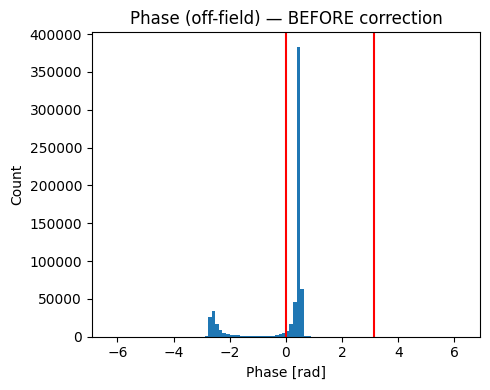

In [239]:
plt.figure(figsize=(5,4))
plt.hist(pha_off_field.ravel(), bins=100)
plt.title("Phase (off-field) — BEFORE correction")
plt.xlabel("Phase [rad]"); plt.ylabel("Count")
plt.axvline(0, color='red'); plt.axvline(np.pi, color='red')
plt.tight_layout()

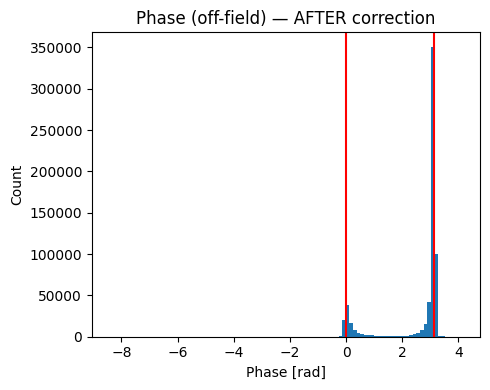

In [240]:
# --- Correction ---
min_ = np.min(pha_off_field)
max_ = np.max(pha_off_field)

pha_correct = np.where(pha_off_field > 1.5,
                       pha_off_field + (min_ - max_),
                       pha_off_field)
pha_correct = pha_correct + np.pi - 0.5

# (optional) write back into sho_fit_params (off-field, phase channel)
sho_fit_params[:, :, :, :, 1, 3] = pha_correct

# --- AFTER: histogram ---
plt.figure(figsize=(5,4))
plt.hist(pha_correct.ravel(), bins=100)
plt.title("Phase (off-field) — AFTER correction")
plt.xlabel("Phase [rad]"); plt.ylabel("Count")
plt.axvline(0, color='red'); plt.axvline(np.pi, color='red')
plt.tight_layout()
plt.show()

In [241]:
pha_off_field = pha_correct
print(pha_off_field.shape)

(50, 50, 8, 32)


In [242]:
pola_off_field = amp_off_field*np.cos(pha_off_field)
print(pola_off_field.shape)

(50, 50, 8, 32)


In [243]:
vdc_vec = beps_raw._axes[3].values
freq_vec = beps_raw._axes[5].values
# vdc_vec = np.load('outputs/bak/sho_fit_all_results_corrected_axisXY-phasePeak.npz')['vdc_vec']
# freq_vec = np.load('outputs/bak/sho_fit_all_results_corrected_axisXY-phasePeak.npz')['freq_vec']

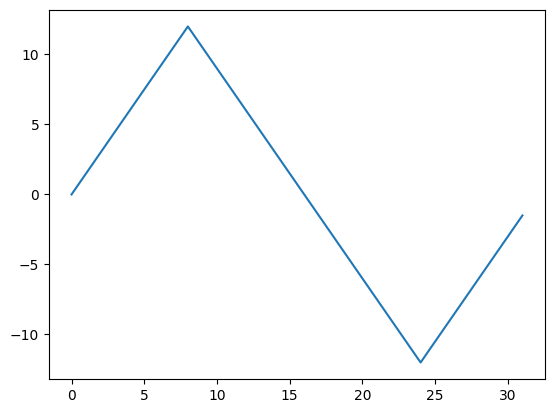

In [244]:
plt.plot(vdc_vec)

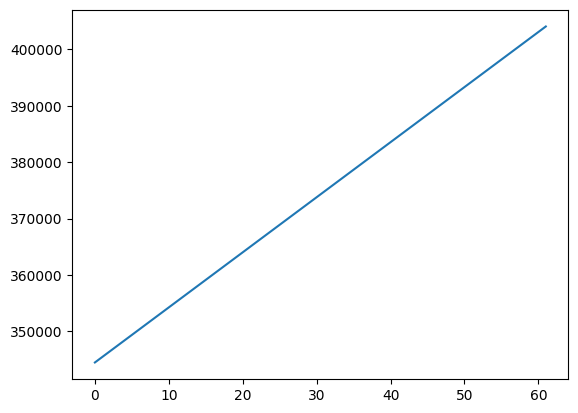

In [245]:
plt.plot(freq_vec)

(256,) (50, 50, 256) (50, 50, 256) (50, 50, 256)


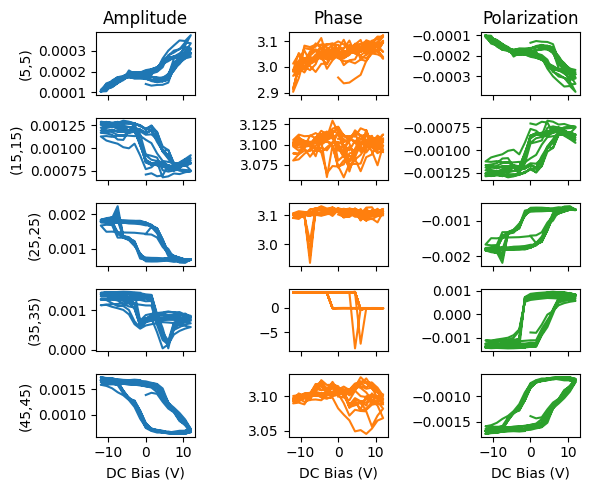

In [246]:
vdc_vec2 = np.tile(vdc_vec, 8)  # length 256
amp_off_field2 = amp_off_field.reshape(50, 50, -1)
pha_off_field2 = pha_off_field.reshape(50, 50, -1)
pola_off_field2 = pola_off_field.reshape(50, 50, -1)
print(vdc_vec2.shape, amp_off_field2.shape, pha_off_field2.shape, pola_off_field2.shape)

rows, cols = 5, 3
indices = [5, 15, 25, 35, 45]  # i and j values
fig, axes = plt.subplots(rows, cols, figsize=(6, 5), sharex=True)
for r, i in enumerate(indices):
    j = indices[r]
    axes[r, 0].plot(vdc_vec2, amp_off_field2[i, j, :], color='tab:blue')
    axes[r, 0].set_ylabel(f"({i},{j})")
    axes[r, 1].plot(vdc_vec2, pha_off_field2[i, j, :], color='tab:orange')
    axes[r, 2].plot(vdc_vec2, pola_off_field2[i, j, :], color='tab:green')

# Labels and titles
for c, title in enumerate(["Amplitude", "Phase", "Polarization"]):
    axes[0, c].set_title(title)

for ax in axes[-1, :]:
    ax.set_xlabel("DC Bias (V)")

plt.tight_layout()
plt.show()

In [247]:
print(img.shape, vdc_vec2.shape)

(50, 50) (256,)


In [248]:
## noisy

In [249]:
## check 1: does this need axis correction? no, currently having (ny, nx, ncycle, ndc, nfield, nfreq) is good but check by plotting img with origin lower.

In [250]:
import numpy as np
import matplotlib.pyplot as plt

In [251]:
data = np.load(f"outputs/2b_fit_data_noisy.npz")
sho_fit_params = data["sho_fit_params"]
sho_fit_curves = data["sho_fit_curves"]
sho_fit_r2 = data["sho_fit_r2"]

print(sho_fit_params.shape, sho_fit_curves.shape, sho_fit_r2.shape)

(50, 50, 8, 32, 2, 4) (50, 50, 8, 32, 2, 124) (50, 50, 8, 32, 2)


(array([3.00000e+00, 3.20000e+01, 3.26000e+02, 1.95816e+05, 1.91310e+05,
        3.57100e+03, 7.12000e+03, 1.34370e+04, 2.93150e+04, 8.39070e+05]),
 array([-0.61199155, -0.45090069, -0.28980984, -0.12871898,  0.03237188,
         0.19346273,  0.35455359,  0.51564444,  0.6767353 ,  0.83782616,
         0.99891701]),
 <BarContainer object of 10 artists>)

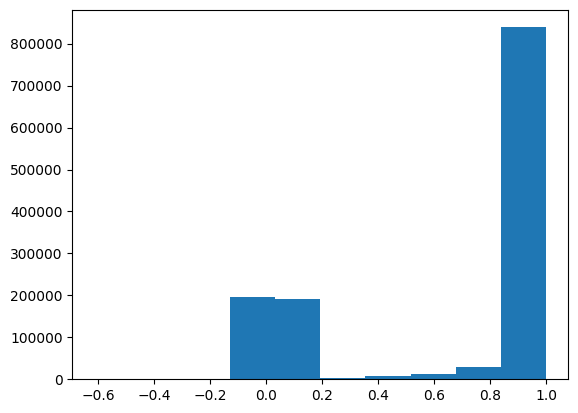

In [252]:
plt.hist(sho_fit_r2.flatten())

(50, 50, 8, 32)
(50, 50)


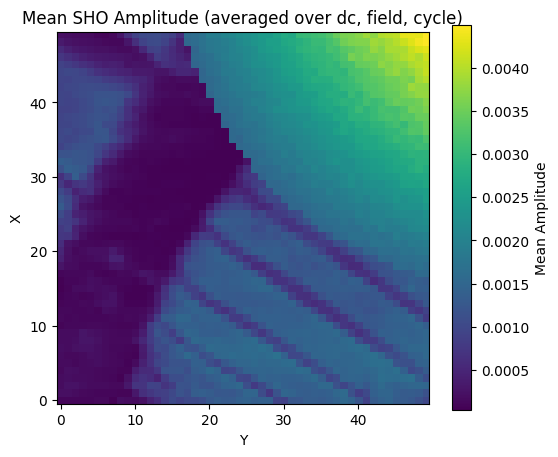

In [253]:
amp_off_field = sho_fit_params[:, :, :, :, 1, 0]
print(amp_off_field.shape)
img_noisy = amp_off_field.mean(axis=(2, 3))
print(img_noisy.shape)  # → (50, 50)
plt.figure(figsize=(6,5))
plt.imshow(img_noisy, cmap='viridis', origin='lower')
plt.colorbar(label='Mean Amplitude')
plt.title('Mean SHO Amplitude (averaged over dc, field, cycle)')
plt.xlabel('Y')
plt.ylabel('X')
plt.show()

In [254]:
## check2: does this need phase correction? check if the peak is in 0 and pi

In [255]:
pha_off_field = sho_fit_params[:, :, :, :, 1, 3]
print(pha_off_field.shape)

(50, 50, 8, 32)


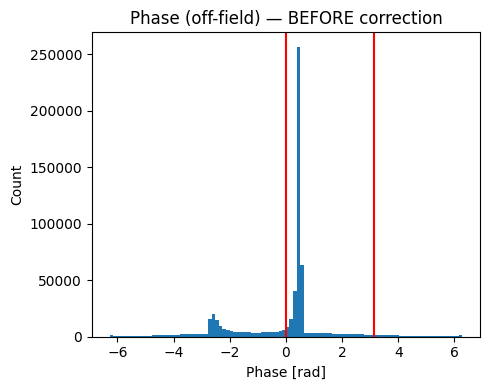

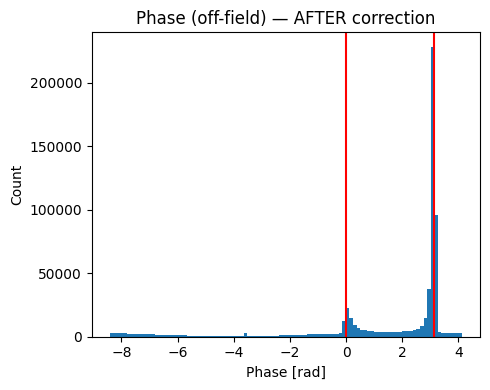

(50, 50, 8, 32)


In [256]:
plt.figure(figsize=(5,4))
plt.hist(pha_off_field.ravel(), bins=100)
plt.title("Phase (off-field) — BEFORE correction")
plt.xlabel("Phase [rad]"); plt.ylabel("Count")
plt.axvline(0, color='red'); plt.axvline(np.pi, color='red')
plt.tight_layout()

# --- Correction ---
min_ = np.min(pha_off_field)
max_ = np.max(pha_off_field)

pha_correct = np.where(pha_off_field > 1.5,
                       pha_off_field + (min_ - max_),
                       pha_off_field)
pha_correct = pha_correct + np.pi - 0.5

# (optional) write back into sho_fit_params (off-field, phase channel)
sho_fit_params[:, :, :, :, 1, 3] = pha_correct

# --- AFTER: histogram ---
plt.figure(figsize=(5,4))
plt.hist(pha_correct.ravel(), bins=100)
plt.title("Phase (off-field) — AFTER correction")
plt.xlabel("Phase [rad]"); plt.ylabel("Count")
plt.axvline(0, color='red'); plt.axvline(np.pi, color='red')
plt.tight_layout()
plt.show()

pha_off_field = pha_correct
print(pha_off_field.shape)

In [257]:
pola_off_field = amp_off_field*np.cos(pha_off_field)
print(pola_off_field.shape)

(50, 50, 8, 32)


In [258]:
vdc_vec = beps_raw._axes[3].values
freq_vec = beps_raw._axes[5].values
# vdc_vec = np.load('outputs/bak/sho_fit_all_results_corrected_axisXY-phasePeak.npz')['vdc_vec']
# freq_vec = np.load('outputs/bak/sho_fit_all_results_corrected_axisXY-phasePeak.npz')['freq_vec']

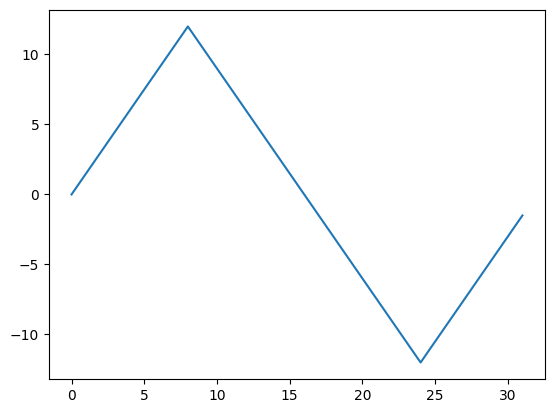

In [259]:
plt.plot(vdc_vec)

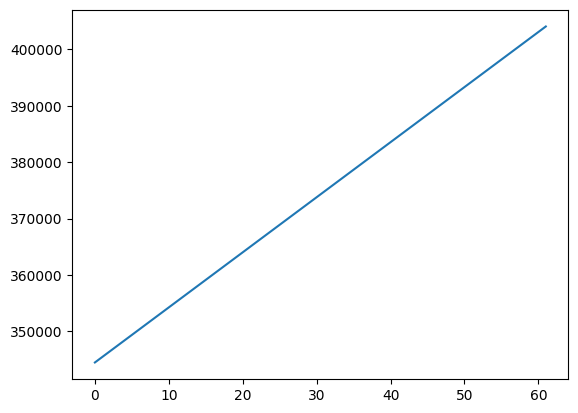

In [260]:
plt.plot(freq_vec)

(256,) (50, 50, 256) (50, 50, 256) (50, 50, 256)


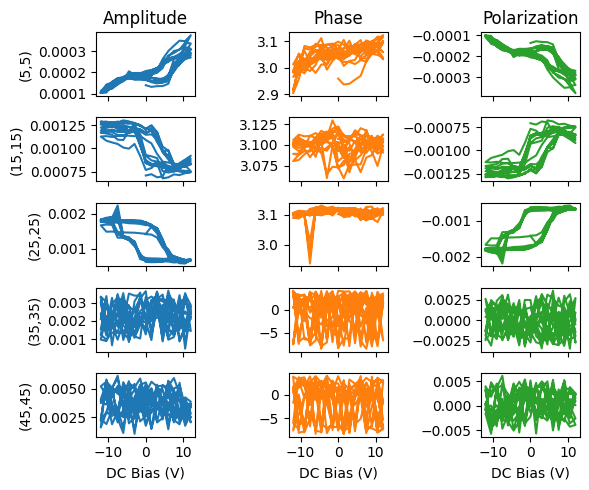

In [261]:
vdc_vec2 = np.tile(vdc_vec, 8)  # length 256
amp_off_field2 = amp_off_field.reshape(50, 50, -1)
pha_off_field2 = pha_off_field.reshape(50, 50, -1)
pola_off_field2 = pola_off_field.reshape(50, 50, -1)
print(vdc_vec2.shape, amp_off_field2.shape, pha_off_field2.shape, pola_off_field2.shape)

rows, cols = 5, 3
indices = [5, 15, 25, 35, 45]  # i and j values
fig, axes = plt.subplots(rows, cols, figsize=(6, 5), sharex=True)
for r, i in enumerate(indices):
    j = indices[r]
    axes[r, 0].plot(vdc_vec2, amp_off_field2[i, j, :], color='tab:blue')
    axes[r, 0].set_ylabel(f"({i},{j})")
    axes[r, 1].plot(vdc_vec2, pha_off_field2[i, j, :], color='tab:orange')
    axes[r, 2].plot(vdc_vec2, pola_off_field2[i, j, :], color='tab:green')

# Labels and titles
for c, title in enumerate(["Amplitude", "Phase", "Polarization"]):
    axes[0, c].set_title(title)

for ax in axes[-1, :]:
    ax.set_xlabel("DC Bias (V)")

plt.tight_layout()
plt.show()

In [262]:
sho_fit_r2.shape

(50, 50, 8, 32, 2)

In [263]:
r2_off_field = sho_fit_r2[:, :, :, :, 1]
print(r2_off_field.shape)
r2_off_field_mean = r2_off_field.mean(axis=(2, 3))
print(r2_off_field_mean.shape)

(50, 50, 8, 32)
(50, 50)


(array([ 751.,    0.,    0.,    0.,    0.,    6.,   31.,   99.,  178.,
        1435.]),
 array([0.03046678, 0.12708949, 0.2237122 , 0.32033491, 0.41695761,
        0.51358032, 0.61020303, 0.70682574, 0.80344844, 0.90007115,
        0.99669386]),
 <BarContainer object of 10 artists>)

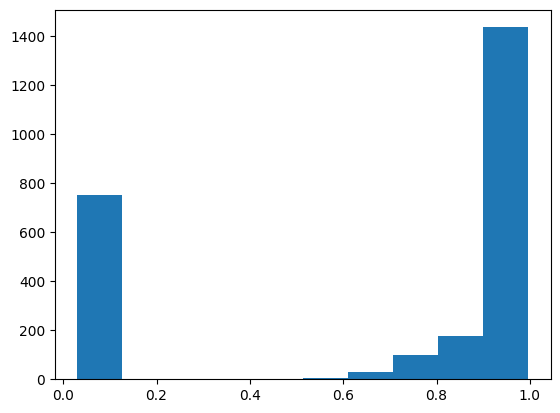

In [264]:
plt.hist(r2_off_field_mean.flatten())

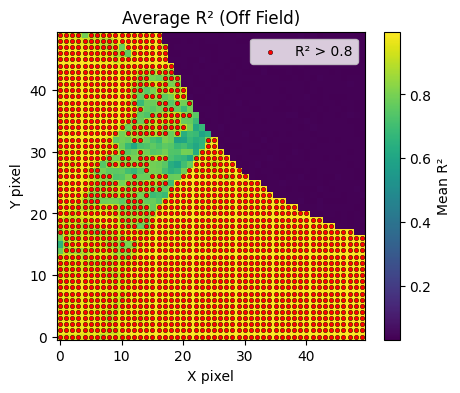

In [265]:
plt.figure(figsize=(5, 4))
plt.imshow(r2_off_field_mean, cmap='viridis', origin='lower')
plt.colorbar(label='Mean R²')
plt.title('Average R² (Off Field)')
plt.xlabel('X pixel')
plt.ylabel('Y pixel')
mask = r2_off_field_mean > 0.8
y, x = np.where(mask)
plt.scatter(x, y, s=10, c='red', marker='o', edgecolors='k', linewidths=0.3, label='R² > 0.8')
plt.legend()
plt.show()

R² min: 0.0305 at pixel (np.int64(20), np.int64(45))
R² max: 0.9967 at pixel (np.int64(28), np.int64(0))


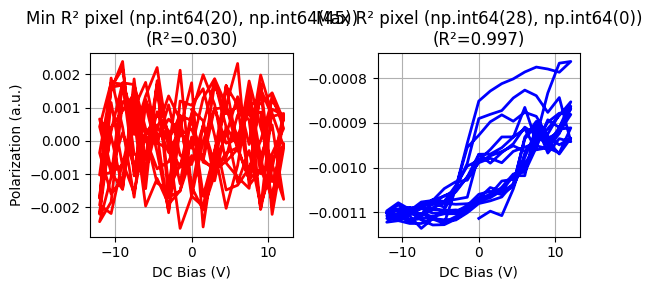

In [266]:
# --- Print min and max values ---
r2_min = r2_off_field_mean.min()
r2_max = r2_off_field_mean.max()

min_idx = np.unravel_index(np.argmin(r2_off_field_mean), r2_off_field_mean.shape)
max_idx = np.unravel_index(np.argmax(r2_off_field_mean), r2_off_field_mean.shape)

print(f"R² min: {r2_min:.4f} at pixel {min_idx}")
print(f"R² max: {r2_max:.4f} at pixel {max_idx}")

# --- Extract polarization loops ---
pola_min = pola_off_field2[min_idx[0], min_idx[1], :]
pola_max = pola_off_field2[max_idx[0], max_idx[1], :]

fig, axes = plt.subplots(1, 2, figsize=(6, 3), sharey=False)

# --- Min R² pixel ---
axes[0].plot(vdc_vec2, pola_min, 'r-', lw=2)
axes[0].set_title(f"Min R² pixel {min_idx}\n(R²={r2_min:.3f})")
axes[0].set_xlabel("DC Bias (V)")
axes[0].set_ylabel("Polarization (a.u.)")
axes[0].grid(True)

# --- Max R² pixel ---
axes[1].plot(vdc_vec2, pola_max, 'b-', lw=2)
axes[1].set_title(f"Max R² pixel {max_idx}\n(R²={r2_max:.3f})")
axes[1].set_xlabel("DC Bias (V)")
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [267]:
print(pola_off_field2.shape, r2_off_field_mean.shape)

(50, 50, 256) (50, 50)


In [268]:
## save information 

In [269]:
print(img_noisy.shape, vdc_vec2.shape, pola_off_field2.shape, r2_off_field_mean.shape)

(50, 50) (256,) (50, 50, 256) (50, 50)


In [270]:
np.savez_compressed(
    f"outputs/{exp_no}_correct_save_data.npz",
    img=img,
    vdc_vec2=vdc_vec2,
    pola_off_field2=pola_off_field2,
    r2_off_field_mean=r2_off_field_mean
)

In [271]:
# data = np.load(f"outputs/2c_correct_save_data.npz")
# img = data["img"]
# vdc_vec = data["vdc_vec2"]
# spectra = data["pola_off_field2"]
# r2_score = data["r2_off_field_mean"]

# print(img.shape, vdc_vec.shape, spectra.shape, r2_score.shape)